# Módulos y librerías para análisis de datos

En este notebook aprenderemos a organizar programas con **módulos** y a utilizar algunas librerías habituales para comenzar un análisis de datos con Python.

La idea será avanzar desde herramientas que ya vienen con Python hasta librerías externas:

1. Importar módulos de la biblioteca estándar.
2. Crear y utilizar un módulo propio.
3. Representar datos con NumPy.
4. Explorar y resumir datos con pandas.
5. Crear una visualización sencilla con Matplotlib.

> Ejecuta las celdas en orden. Los ejemplos usan datos pequeños para que podamos concentrarnos en las ideas.

## 1. ¿Qué es un módulo?

Un **módulo** es un archivo `.py` que contiene código reutilizable: variables, funciones o clases. Una librería suele reunir varios módulos relacionados.

La biblioteca estándar de Python ya incluye muchos módulos. Para usarlos escribimos `import`:

```python
import modulo
modulo.elemento
```

También podemos importar solo un elemento o asignar un alias:

```python
from modulo import elemento
import modulo as alias
```

Usar módulos evita repetir código y ayuda a mantener los programas ordenados.

In [8]:
import math
import random
from datetime import date

print(f"Pi vale aproximadamente {math.pi:.6f}")
print(f"La raíz cuadrada de 81 es {math.sqrt(81):.0f}")
print(f"Hoy es {date.today()}")
print(f"Número aleatorio entre 1 y 10: {random.randint(1, 10)}")

Pi vale aproximadamente 3.141593
La raíz cuadrada de 81 es 9
Hoy es 2026-08-21
Número aleatorio entre 1 y 10: 9


### Importar de distintas formas

- `import math` importa el módulo completo.
- `from math import pi` importa un elemento concreto.
- `import numpy as np` crea un alias corto y habitual.

Conviene elegir nombres claros y evitar `from modulo import *`, porque puede ocultar de dónde procede cada función.

In [9]:
from math import pi

circunferencia = 2 * pi * 3
print(f"Una circunferencia de radio 3 mide {circunferencia:.2f}")

Una circunferencia de radio 3 mide 18.85


## 2. Crear un módulo propio

Un módulo propio es simplemente otro archivo `.py` en el mismo proyecto. En esta demostración crearemos `operaciones.py` desde una celda y luego lo importaremos.

En un proyecto real, este archivo se puede editar directamente desde el explorador de VS Code.

In [16]:
%%writefile operaciones.py
def calcular_total(precio, cantidad):
    return precio * cantidad

def aplicar_descuento(total, porcentaje):
    return total * (1 - porcentaje / 100)


Overwriting operaciones.py


In [11]:
# Importar sólo las funciones necesarias
from operaciones import calcular_total, aplicar_descuento

subtotal = calcular_total(12.5, 4)
total = aplicar_descuento(subtotal, 10)
print(f"Subtotal: ${subtotal:.2f}")
print(f"Total con descuento: ${total:.2f}")

Subtotal: $50.00
Total con descuento: $45.00


In [12]:
# Importar el módulo completo
import operaciones

subtotal = operaciones.calcular_total(15.0, 3)
total = operaciones.aplicar_descuento(subtotal, 5)

print(f"Subtotal: ${subtotal:.2f}")
print(f"Total con descuento: ${total:.2f}")

Subtotal: $45.00
Total con descuento: $42.75


In [13]:
# Importar el módulo completo con alias
import operaciones as op

subtotal = op.calcular_total(20.0, 2)
total = op.aplicar_descuento(subtotal, 15)

print(f"Subtotal: ${subtotal:.2f}")
print(f"Total con descuento: ${total:.2f}")

Subtotal: $40.00
Total con descuento: $34.00


In [ ]:
# Practica 1:
# Crear un módulo llamado calculos.py que tenga las funciones de calcular area de un triangulo por: 1) base y altura, 2) usando sus tres lados
# Luego utilizar esas funciones en este notebook.

In [19]:
%%writefile calculos.py
def area_base_altura(base, altura):
    return (base * altura) / 2

def area_tres_lados(a, b, c):
    s = (a + b + c) / 2
    return (s * (s - a) * (s - b) * (s - c)) ** 0.5


Writing calculos.py


In [26]:
# Usando el modulo creado
import calculos as cal

# Calcular el area de un triangulo usando la base y la altura
area1 = cal.area_base_altura(10, 3)
print(f"El área del trigulo 1 es: {area1}")

# Calcular el area de un triangulo usando los tres lado
area2 = cal.area_tres_lados(8, 9, 10)
print(f"El área del trigulo 2 es: {area2:.2f}")

El área del trigulo 1 es: 15.0
El área del trigulo 2 es: 34.20


## 3. Librerías para análisis de datos

Una librería es código creado por otras personas que podemos reutilizar. En este notebook usaremos:

- **NumPy**: trabaja con arreglos numéricos y operaciones eficientes.
- **pandas**: organiza datos en tablas y facilita su exploración.
- **Matplotlib**: crea gráficos.

En Python se suelen importar con alias convencionales: `np`, `pd` y `plt`.

### Instalar librerias para el análisis de datos

```bash
python -m pip install numpy pandas matplotlib
```

In [27]:
!python -m pip install numpy pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy", np.__version__)
print("pandas", pd.__version__)

ventas = np.array([120, 150, 90, 180, 160])
print("Ventas:", ventas)
print("Ventas con impuesto del 10%:", ventas * 1.10)
print("Promedio:", ventas.mean())
print("Venta máxima:", ventas.max())

NumPy 2.4.6
pandas 3.0.3
Ventas: [120 150  90 180 160]
Ventas con impuesto del 10%: [132. 165.  99. 198. 176.]
Promedio: 140.0
Venta máxima: 180


### De una lista a una tabla

Un `DataFrame` de pandas representa una tabla con filas y columnas. Podemos construirlo desde un diccionario: cada clave será una columna.

In [30]:
datos = {
    "producto": ["Cuaderno", "Lapicero", "Mochila", "Regla", "Colores"],
    "categoria": ["Papelería", "Papelería", "Accesorios", "Papelería", "Papelería"],
    "precio": [4.5, 1.2, 28.0, 2.0, 6.5],
    "unidades": [12, 35, 5, 18, 10],
}

ventas = pd.DataFrame(datos)
ventas

,producto,categoria,precio,unidades
0,Cuaderno,Papelería,4.5,12
1,Lapicero,Papelería,1.2,35
2,Mochila,Accesorios,28.0,5
3,Regla,Papelería,2.0,18
4,Colores,Papelería,6.5,10


In [32]:
print("Primeras filas:")
display(ventas.head(3))

print("\nInformación general:")
ventas.info()

print("\nResumen numérico:")
display(ventas.describe())

Primeras filas:


,producto,categoria,precio,unidades
0,Cuaderno,Papelería,4.5,12
1,Lapicero,Papelería,1.2,35
2,Mochila,Accesorios,28.0,5



Información general:
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   producto   5 non-null      str    
 1   categoria  5 non-null      str    
 2   precio     5 non-null      float64
 3   unidades   5 non-null      int64  
dtypes: float64(1), int64(1), str(2)
memory usage: 292.0 bytes

Resumen numérico:


,precio,unidades
count,5.000000,5.000000
mean,8.440000,16.000000
std,11.132969,11.597414
min,1.200000,5.000000
25%,2.000000,10.000000
50%,4.500000,12.000000
75%,6.500000,18.000000
max,28.000000,35.000000


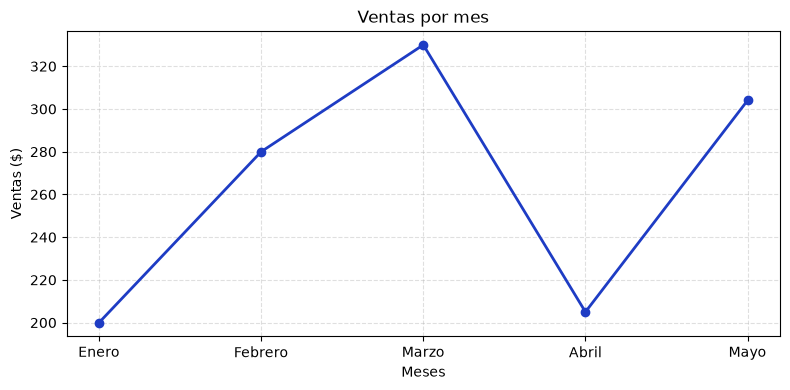

In [36]:
# Usando la libreria matplotlib
import matplotlib.pyplot as plt

ventas = [200, 280, 330, 205, 304]
meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo"]

plt.figure(figsize=(8, 4))
plt.plot(meses, ventas, marker="o", color="#1e3cc4", linewidth=2)
plt.title("Ventas por mes")
plt.xlabel("Meses")
plt.ylabel("Ventas ($)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [39]:
# Creación de un objeto Series con lecturas de Temperaturas
temperaturas = [4.4, 5.1, 6.1, 6.2, 6.1, 6.1, 5.7, 5.2, 4.7, 4.1, 3.9]
serie = pd.Series(temperaturas, name="Temperaturas")

display(serie)

0     4.4
1     5.1
2     6.1
3     6.2
4     6.1
5     6.1
6     5.7
7     5.2
8     4.7
9     4.1
10    3.9
Name: Temperaturas, dtype: float64

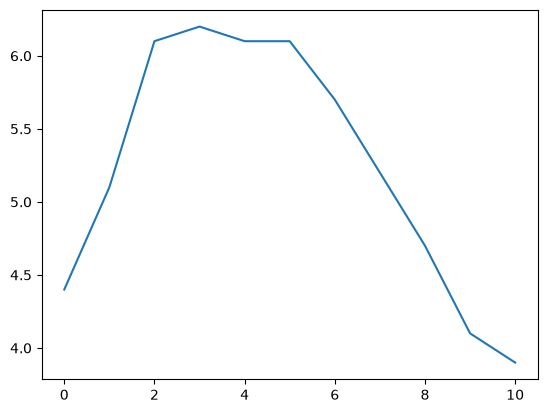

In [40]:
# Graficas los valores de la serie usando matplotlib
import matplotlib.pyplot as plt

# Crear el grafico
serie.plot()
# Mostrar el grafico
plt.show()

### Seleccionar, crear y agrupar

Las expresiones booleanas permiten filtrar filas. También podemos crear columnas nuevas a partir de las existentes y agrupar para comparar categorías.

In [42]:
datos = {
    "producto": ["Cuaderno", "Lapicero", "Mochila", "Regla", "Colores"],
    "categoria": ["Papelería", "Papelería", "Accesorios", "Papelería", "Papelería"],
    "precio": [4.5, 1.2, 28.0, 2.0, 6.5],
    "unidades": [12, 35, 5, 18, 10],
}
ventas = pd.DataFrame(datos)
# Cerear nueva columna
ventas["ingreso"] = ventas["precio"] * ventas["unidades"]
display(ventas)

,producto,categoria,precio,unidades,ingreso
0,Cuaderno,Papelería,4.5,12,54.0
1,Lapicero,Papelería,1.2,35,42.0
2,Mochila,Accesorios,28.0,5,140.0
3,Regla,Papelería,2.0,18,36.0
4,Colores,Papelería,6.5,10,65.0


In [44]:
# Aplicando filtros
productos_caros = ventas[ventas["precio"] > 5] # Filtro: ventas["precio"] > 5
print("Productos con precio mayor que $5:")
display(productos_caros[["producto", "precio", "ingreso"]]) # Columnas seleccionadas: ["producto", "precio", "ingreso"]

Productos con precio mayor que $5:


,producto,precio,ingreso
2,Mochila,28.0,140.0
4,Colores,6.5,65.0


In [45]:
# Agrupando datos
resumen_categoria = (
    ventas.groupby("categoria", as_index=False)["ingreso"]
    .sum()
    .sort_values("ingreso", ascending=False)
)
print("Ingresos por categoría:")
display(resumen_categoria)

Ingresos por categoría:


,categoria,ingreso
1,Papelería,197.0
0,Accesorios,140.0


## 4. Visualizar los resultados

Un gráfico ayuda a detectar diferencias rápidamente. Matplotlib separa la preparación de los datos de su representación visual.

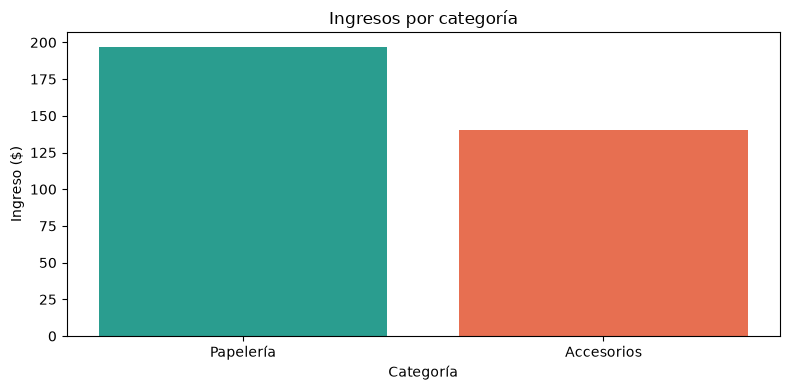

In [46]:
plt.figure(figsize=(8, 4))
plt.bar(resumen_categoria["categoria"], resumen_categoria["ingreso"], color=["#2a9d8f", "#e76f51"])
plt.title("Ingresos por categoría")
plt.xlabel("Categoría")
plt.ylabel("Ingreso ($)")
plt.tight_layout()
plt.show()

## 5. Práctica integradora

Usa pandas para responder estas preguntas sobre las calificaciones:

1. ¿Cuál es el promedio de cada estudiante?
2. ¿Qué estudiantes aprobaron? Considera aprobado un promedio mayor o igual que 60.
3. ¿Cuál es el promedio de la clase?
4. Crea un gráfico de barras con los promedios.

Intenta resolverlo antes de revisar la solución.

,estudiante,python,datos,proyecto,promedio,aprobado
0,Ana,85,78,92,85.000000,True
1,Bruno,72,80,75,75.666667,True
2,Carla,55,61,58,58.000000,False
3,Diego,90,94,88,90.666667,True
4,Elena,68,70,65,67.666667,True


Promedio de la clase: 75.4


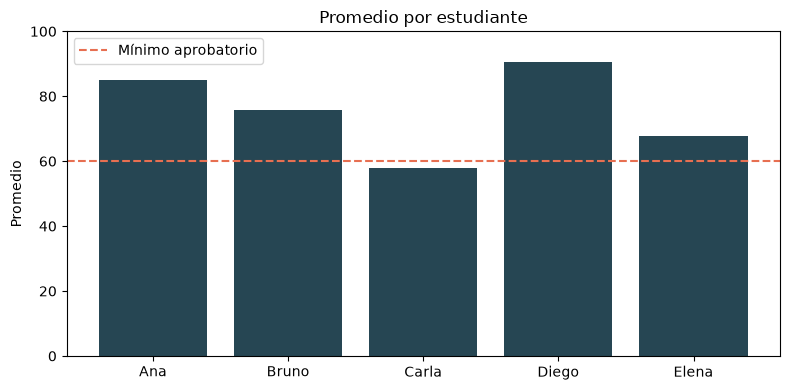

In [47]:
calificaciones = pd.DataFrame({
    "estudiante": ["Ana", "Bruno", "Carla", "Diego", "Elena"],
    "python": [85, 72, 55, 90, 68],
    "datos": [78, 80, 61, 94, 70],
    "proyecto": [92, 75, 58, 88, 65],
})

calificaciones["promedio"] = calificaciones[["python", "datos", "proyecto"]].mean(axis=1)
calificaciones["aprobado"] = calificaciones["promedio"] >= 60

display(calificaciones)
print(f"Promedio de la clase: {calificaciones['promedio'].mean():.1f}")

plt.figure(figsize=(8, 4))
plt.bar(calificaciones["estudiante"], calificaciones["promedio"], color="#264653")
plt.axhline(60, color="#e76f51", linestyle="--", label="Mínimo aprobatorio")
plt.ylim(0, 100)
plt.title("Promedio por estudiante")
plt.ylabel("Promedio")
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
# Cargar un archivo CSV con pandas
import pandas as pd

ruta_archivo = "./data/alumnos.csv"
df_alumnos = pd.read_csv(ruta_archivo)

# Mostrar los primeros 5 registros
df_alumnos.head(5)

,CodAlumno,Nombres,Apellidos,DNI,FechaNacimiento,Email,Direccion,Sexo,Distrito,Provincia,Departamento
0,1,MARIA FERNANDA,VAZQUES QUESQUEN,70671235,22/10/1998,mafer98@gmail.com,AV. AREQUIPA 1245,F,SAN BORJA,LIMA,LIMA
1,2,JUAN LUIS,MARTINEZ SALAS,68907812,18/05/1992,juanmasa@gmail.com,JR. CARABAYA 2210,M,SANTIAGO DE SURCO,LIMA,LIMA
2,5,ANTONIO,RAMOS SOTO,62562312,9/11/1991,antonysoto@gmail.com,CALLE LOS QUENUALES 890,M,LINCE,LIMA,LIMA
3,8,ANTONIO,ANDRADE GARCIA,45908967,13/10/1989,antonio2020@gmail.com,AV. ABANCAY S/N,M,SURQUILLO,LIMA,LIMA
4,19,ALICIA,VARGAS SOTO,50405678,10/12/1993,aliciavargas110@gmail.com,AV. ABANCAY S/N,F,ICA,ICA,ICA


In [49]:
# Seleccionar solo las siguientes columnas: Nombres, Apellidos, DNI, Sexo
columnas_selecionadas = ["Nombres", "Apellidos", "DNI", "Sexo"]
df_alumnos[columnas_selecionadas].head(5)

,Nombres,Apellidos,DNI,Sexo
0,MARIA FERNANDA,VAZQUES QUESQUEN,70671235,F
1,JUAN LUIS,MARTINEZ SALAS,68907812,M
2,ANTONIO,RAMOS SOTO,62562312,M
3,ANTONIO,ANDRADE GARCIA,45908967,M
4,ALICIA,VARGAS SOTO,50405678,F


In [ ]:
# Filtrar solo a los alumnos del Distrito de San Borja mostrando las colummas seleccionadas en el ejercicio anterior
df_san_borja = df_alumnos[df_alumnos["Distrito"]=='SAN BORJA'] #filtro: df_alumnos["Distrito"]=='SAN BORJA'
df_san_borja[columnas_selecionadas]

,Nombres,Apellidos,DNI,Sexo
0,MARIA FERNANDA,VAZQUES QUESQUEN,70671235,F
12,SAUL,SANTILLAN MENDOZA,48553322,M
615,ANDREA CAROLINA,MAYORGA JARAMILLO,47804728,M
616,MARIELA RAFAELA,OCHOA PELAES,40748437,F
617,NICOLÁS ANDRE,ISLA GARCIA,12345678,M
618,PABLO SAMUEL,NUÑEZ MELGAR LEON,72115670,M


In [52]:
# Mostrar el nombre, apellido y direccion de los alumnos del departamento de ICA
alumnos_ica = df_alumnos[df_alumnos["Departamento"]=='ICA']
alumnos_ica[["Nombres", "Apellidos", "Direccion"]]

,Nombres,Apellidos,Direccion
4,ALICIA,VARGAS SOTO,AV. ABANCAY S/N
5,JUAN LUIS,GUTIERREZ GIRON,AV. ABANCAY S/N
14,ROSA MARIA,PARACIOS VARGAS,AV. ABANCAY S/N
512,JESUS ARMANDO,LURITA ACEVEDO,URB. VILLA SARAJA D-5
513,OSCAR JESÚS,CUCHO MONTALVO,URB SAN JOAQUÍN II ETAPA P-39
514,JOHN DANILO,CARHUAS RAMIREZ,CALLE SIMON BOLIVAR 442


<Axes: xlabel='Departamento'>

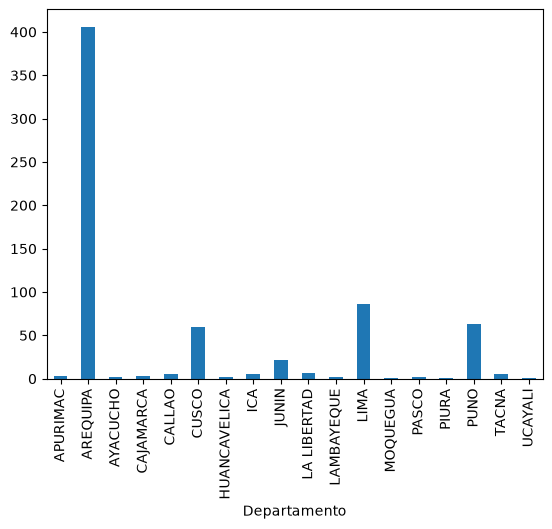

In [61]:
# Agrupar los alumnos por departamento y hacer el conteo, luego generar un grafico de barras
alumnos_dpto = df_alumnos.groupby("Departamento")["CodAlumno"]
alumnos_dpto.count().plot.bar()

## 6. Ideas clave

- Un módulo es un archivo reutilizable; se incorpora con `import`.
- La biblioteca estándar viene con Python; las librerías externas se instalan una vez en el entorno.
- NumPy facilita el trabajo con arreglos numéricos.
- pandas organiza datos tabulares en `DataFrame` y ofrece operaciones como `head`, `describe`, filtros y `groupby`.
- Matplotlib permite comunicar resultados mediante gráficos.

### Para seguir practicando

Elige otro conjunto de datos pequeño, crea un `DataFrame`, añade una columna calculada, aplica un filtro, agrupa por una categoría y representa el resultado con un gráfico. Explica con una frase qué conclusión obtienes.